In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
sns.set(style="whitegrid")

In [7]:
# Load the dataset
df = pd.read_csv("website_traffic.csv")

# View first rows
df.head()

,user_id,page,session_duration,traffic_source,bounce,entry_page,exit_page
0,1,Contact,493,Referral,0,Checkout,Home
1,2,Home,195,Referral,1,Checkout,Home
2,3,Home,452,Referral,0,Blog,Contact
3,4,Checkout,479,Direct,0,Products,Products
4,5,Contact,401,Direct,1,Contact,Home


In [9]:
# Check dataset structure
df.info()

# Check missing values
df.isnull().sum()

# Basic statistics
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           1000 non-null   int64
 1   page              1000 non-null   str  
 2   session_duration  1000 non-null   int64
 3   traffic_source    1000 non-null   str  
 4   bounce            1000 non-null   int64
 5   entry_page        1000 non-null   str  
 6   exit_page         1000 non-null   str  
dtypes: int64(3), str(4)
memory usage: 54.8 KB


,user_id,session_duration,bounce
count,1000.000000,1000.000000,1000.00000
mean,500.500000,306.376000,0.51000
std,288.819436,169.081641,0.50015
min,1.000000,10.000000,0.00000
25%,250.750000,161.000000,0.00000
50%,500.500000,300.000000,1.00000
75%,750.250000,453.000000,1.00000
max,1000.000000,599.000000,1.00000


In [10]:
# Remove duplicates if any
df = df.drop_duplicates()

# Convert bounce to categorical
df['bounce'] = df['bounce'].astype('category')

# Check cleaned data
df.head()

,user_id,page,session_duration,traffic_source,bounce,entry_page,exit_page
0,1,Contact,493,Referral,0,Checkout,Home
1,2,Home,195,Referral,1,Checkout,Home
2,3,Home,452,Referral,0,Blog,Contact
3,4,Checkout,479,Direct,0,Products,Products
4,5,Contact,401,Direct,1,Contact,Home


In [11]:
total_page_views = df['page'].value_counts()
print("Page Views:\n", total_page_views)

Page Views:
 page
Contact     226
Blog        200
Checkout    199
Home        189
Products    186
Name: count, dtype: int64


In [12]:
bounce_rate = df['bounce'].value_counts(normalize=True) * 100
print("Bounce Rate:\n", bounce_rate)

Bounce Rate:
 bounce
1    51.0
0    49.0
Name: proportion, dtype: float64


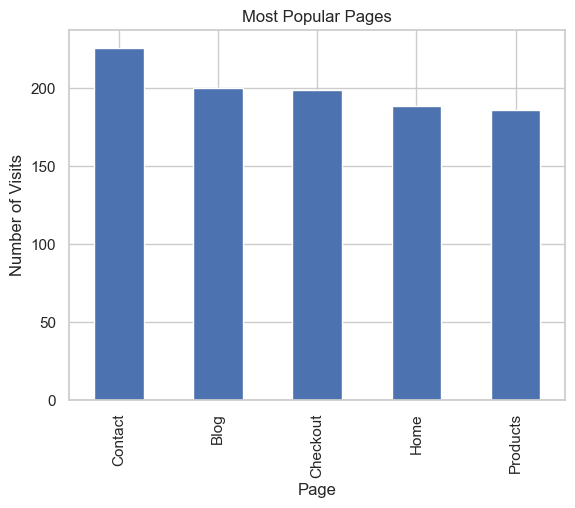

In [13]:
popular_pages = df['page'].value_counts()

plt.figure()
popular_pages.plot(kind='bar')
plt.title("Most Popular Pages")
plt.xlabel("Page")
plt.ylabel("Number of Visits")
plt.show()

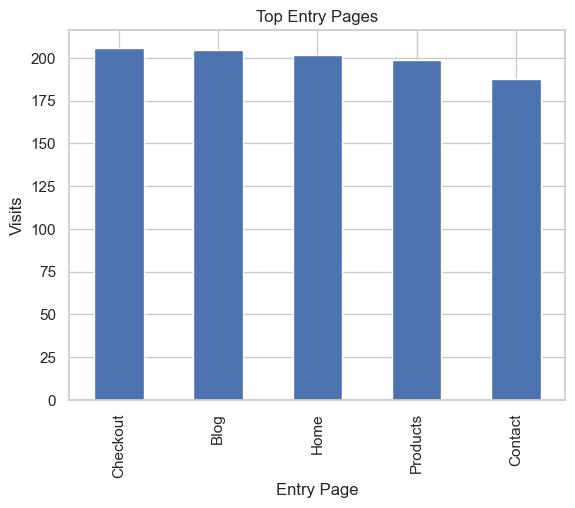

In [14]:
entry_pages = df['entry_page'].value_counts()

plt.figure()
entry_pages.plot(kind='bar')
plt.title("Top Entry Pages")
plt.xlabel("Entry Page")
plt.ylabel("Visits")
plt.show()

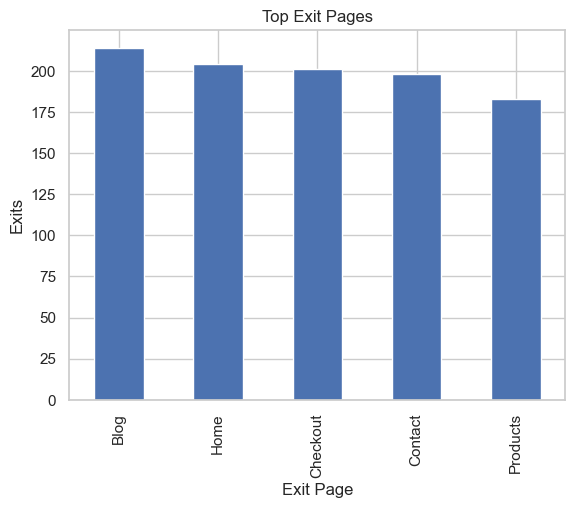

In [15]:
exit_pages = df['exit_page'].value_counts()

plt.figure()
exit_pages.plot(kind='bar')
plt.title("Top Exit Pages")
plt.xlabel("Exit Page")
plt.ylabel("Exits")
plt.show()

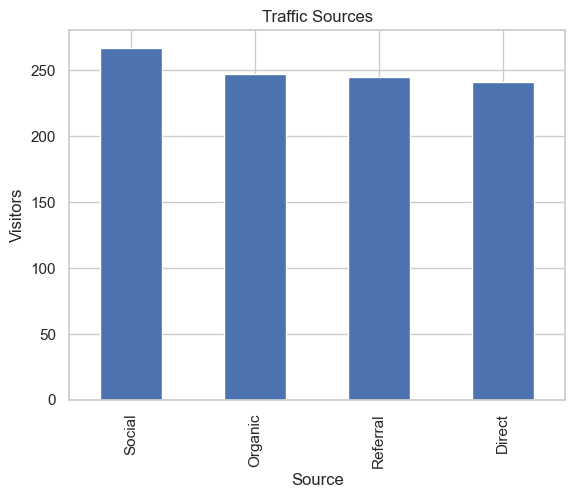

In [16]:
traffic_sources = df['traffic_source'].value_counts()

plt.figure()
traffic_sources.plot(kind='bar')
plt.title("Traffic Sources")
plt.xlabel("Source")
plt.ylabel("Visitors")
plt.show()

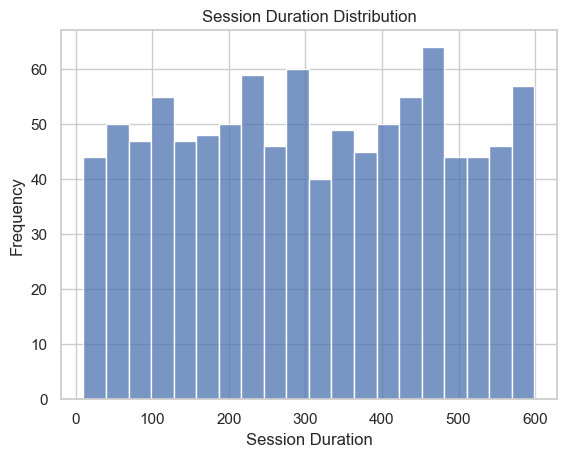

In [17]:
plt.figure()
sns.histplot(df['session_duration'], bins=20)
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration")
plt.ylabel("Frequency")
plt.show()

In [18]:
navigation = df.groupby(['entry_page','exit_page']).size().reset_index(name='count')
navigation.sort_values(by='count', ascending=False).head(10)

,entry_page,exit_page,count
6,Checkout,Checkout,49
10,Contact,Blog,47
8,Checkout,Home,46
21,Products,Checkout,46
0,Blog,Blog,45
17,Home,Contact,45
4,Blog,Products,44
13,Contact,Home,43
2,Blog,Contact,43
16,Home,Checkout,43


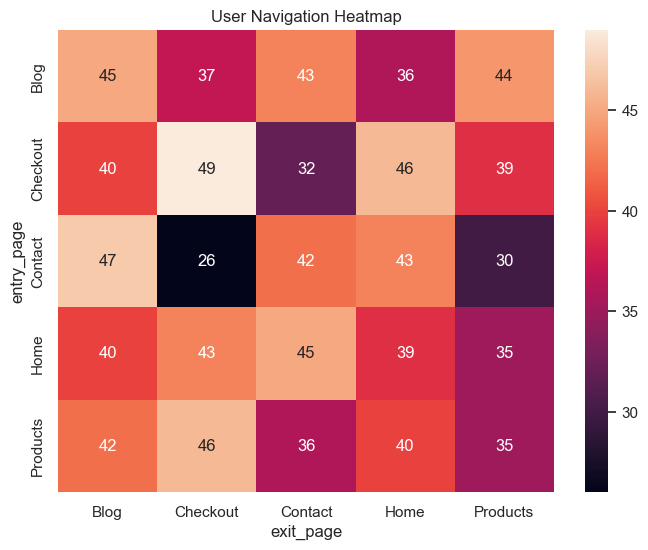

In [19]:
nav_matrix = pd.crosstab(df['entry_page'], df['exit_page'])

plt.figure(figsize=(8,6))
sns.heatmap(nav_matrix, annot=True, fmt="d")
plt.title("User Navigation Heatmap")
plt.show()

In [20]:
print("INSIGHTS")

print("1. Most visited page:", df['page'].value_counts().idxmax())

print("2. Page where most users enter:", df['entry_page'].value_counts().idxmax())

print("3. Page where most users exit:", df['exit_page'].value_counts().idxmax())

print("4. Average session duration:", df['session_duration'].mean())

INSIGHTS
1. Most visited page: Contact
2. Page where most users enter: Checkout
3. Page where most users exit: Blog
4. Average session duration: 306.376


In [21]:
print("RECOMMENDATIONS")

print("• Improve pages with high exit rates.")
print("• Optimize entry pages to guide users to other sections.")
print("• Reduce bounce rate by improving page loading speed.")
print("• Improve content on pages with low session duration.")
print("• Focus marketing on top traffic sources.")

RECOMMENDATIONS
• Improve pages with high exit rates.
• Optimize entry pages to guide users to other sections.
• Reduce bounce rate by improving page loading speed.
• Improve content on pages with low session duration.
• Focus marketing on top traffic sources.
